In [ ]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Targets: P_solar_total, Vbat, Tbatt
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# ============================================================
# SECTION 1: DATA LOADING
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TSURU_cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Targets
TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

# TimeSeriesSplit — correct for on-orbit time series data
tscv     = TimeSeriesSplit(n_splits=5)
splits   = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

# Target-specific leakage-free feature sets
# (P=V*I leakage, Vbat self-prediction, DeltaT reconstruction
#  all explained in 03_Polynomial_Regression.ipynb)

FEATURES_SOLAR = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_VBAT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_TBATT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)', 'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

datasets = {
    'Primary'  : (df[FEATURES_SOLAR],  df[TARGET_PRIMARY],   FEATURES_SOLAR),
    'Secondary': (df[FEATURES_VBAT],   df[TARGET_SECONDARY], FEATURES_VBAT),
    'Tertiary' : (df[FEATURES_TBATT],  df[TARGET_TERTIARY],  FEATURES_TBATT)
}

print(f"\nFeatures for P_solar_total : {len(FEATURES_SOLAR)}")
print(f"Features for Vbat          : {len(FEATURES_VBAT)}")
print(f"Features for Tbatt         : {len(FEATURES_TBATT)}")
print(f"Train size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")

Mounted at /content/drive
Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Features for P_solar_total : 12
Features for Vbat          : 12
Features for Tbatt         : 13
Train size : 19383
Test size  : 3876


In [3]:
# ============================================================
# SECTION 2: TRAINING OPTIMIZATION — OLS MINIMIZATION
# Multiple Linear Regression fits the hyperplane:
# y = b0 + b1*x1 + b2*x2 + ... + bn*xn
# Coefficients optimized by minimizing Sum of Squared Residuals
# ============================================================

results_before = {}

print("=" * 65)
print("TRAINING OPTIMIZATION — OLS COEFFICIENT MINIMIZATION")
print("=" * 65)
print("P_solar_total : 12 features (currents removed — V*I leakage)")
print("Vbat          : 12 features (Vbat removed — self-prediction)")
print("Tbatt         : 13 features (DeltaT removed — arithmetic leak)")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    model  = LinearRegression()   # OLS solver
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results_before[name] = {
        'MSE'   : mse,
        'RMSE'  : rmse,
        'MAE'   : mae,
        'R2'    : r2,
        'y_pred': y_pred,
        'y_test': y_test,
        'model' : model,
        'scaler': scaler,
        'feats' : feats
    }

    print(f"\nTarget   : {y.name}")
    print(f"Features : {len(feats)}")
    print(f"R2       : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"MSE      : {mse:.4f}")

TRAINING OPTIMIZATION — OLS COEFFICIENT MINIMIZATION
P_solar_total : 12 features (currents removed — V*I leakage)
Vbat          : 12 features (Vbat removed — self-prediction)
Tbatt         : 13 features (DeltaT removed — arithmetic leak)

Target   : P_solar_total (µW)
Features : 12
R2       : 0.6318
RMSE     : 537307.4509
MAE      : 363370.3991
MSE      : 288699296765.2748

Target   : Vbat (V)
Features : 12
R2       : 0.8234
RMSE     : 0.0379
MAE      : 0.0266
MSE      : 0.0014

Target   : Tbatt (℃)
Features : 13
R2       : -0.4315
RMSE     : 6.2034
MAE      : 3.6952
MSE      : 38.4826


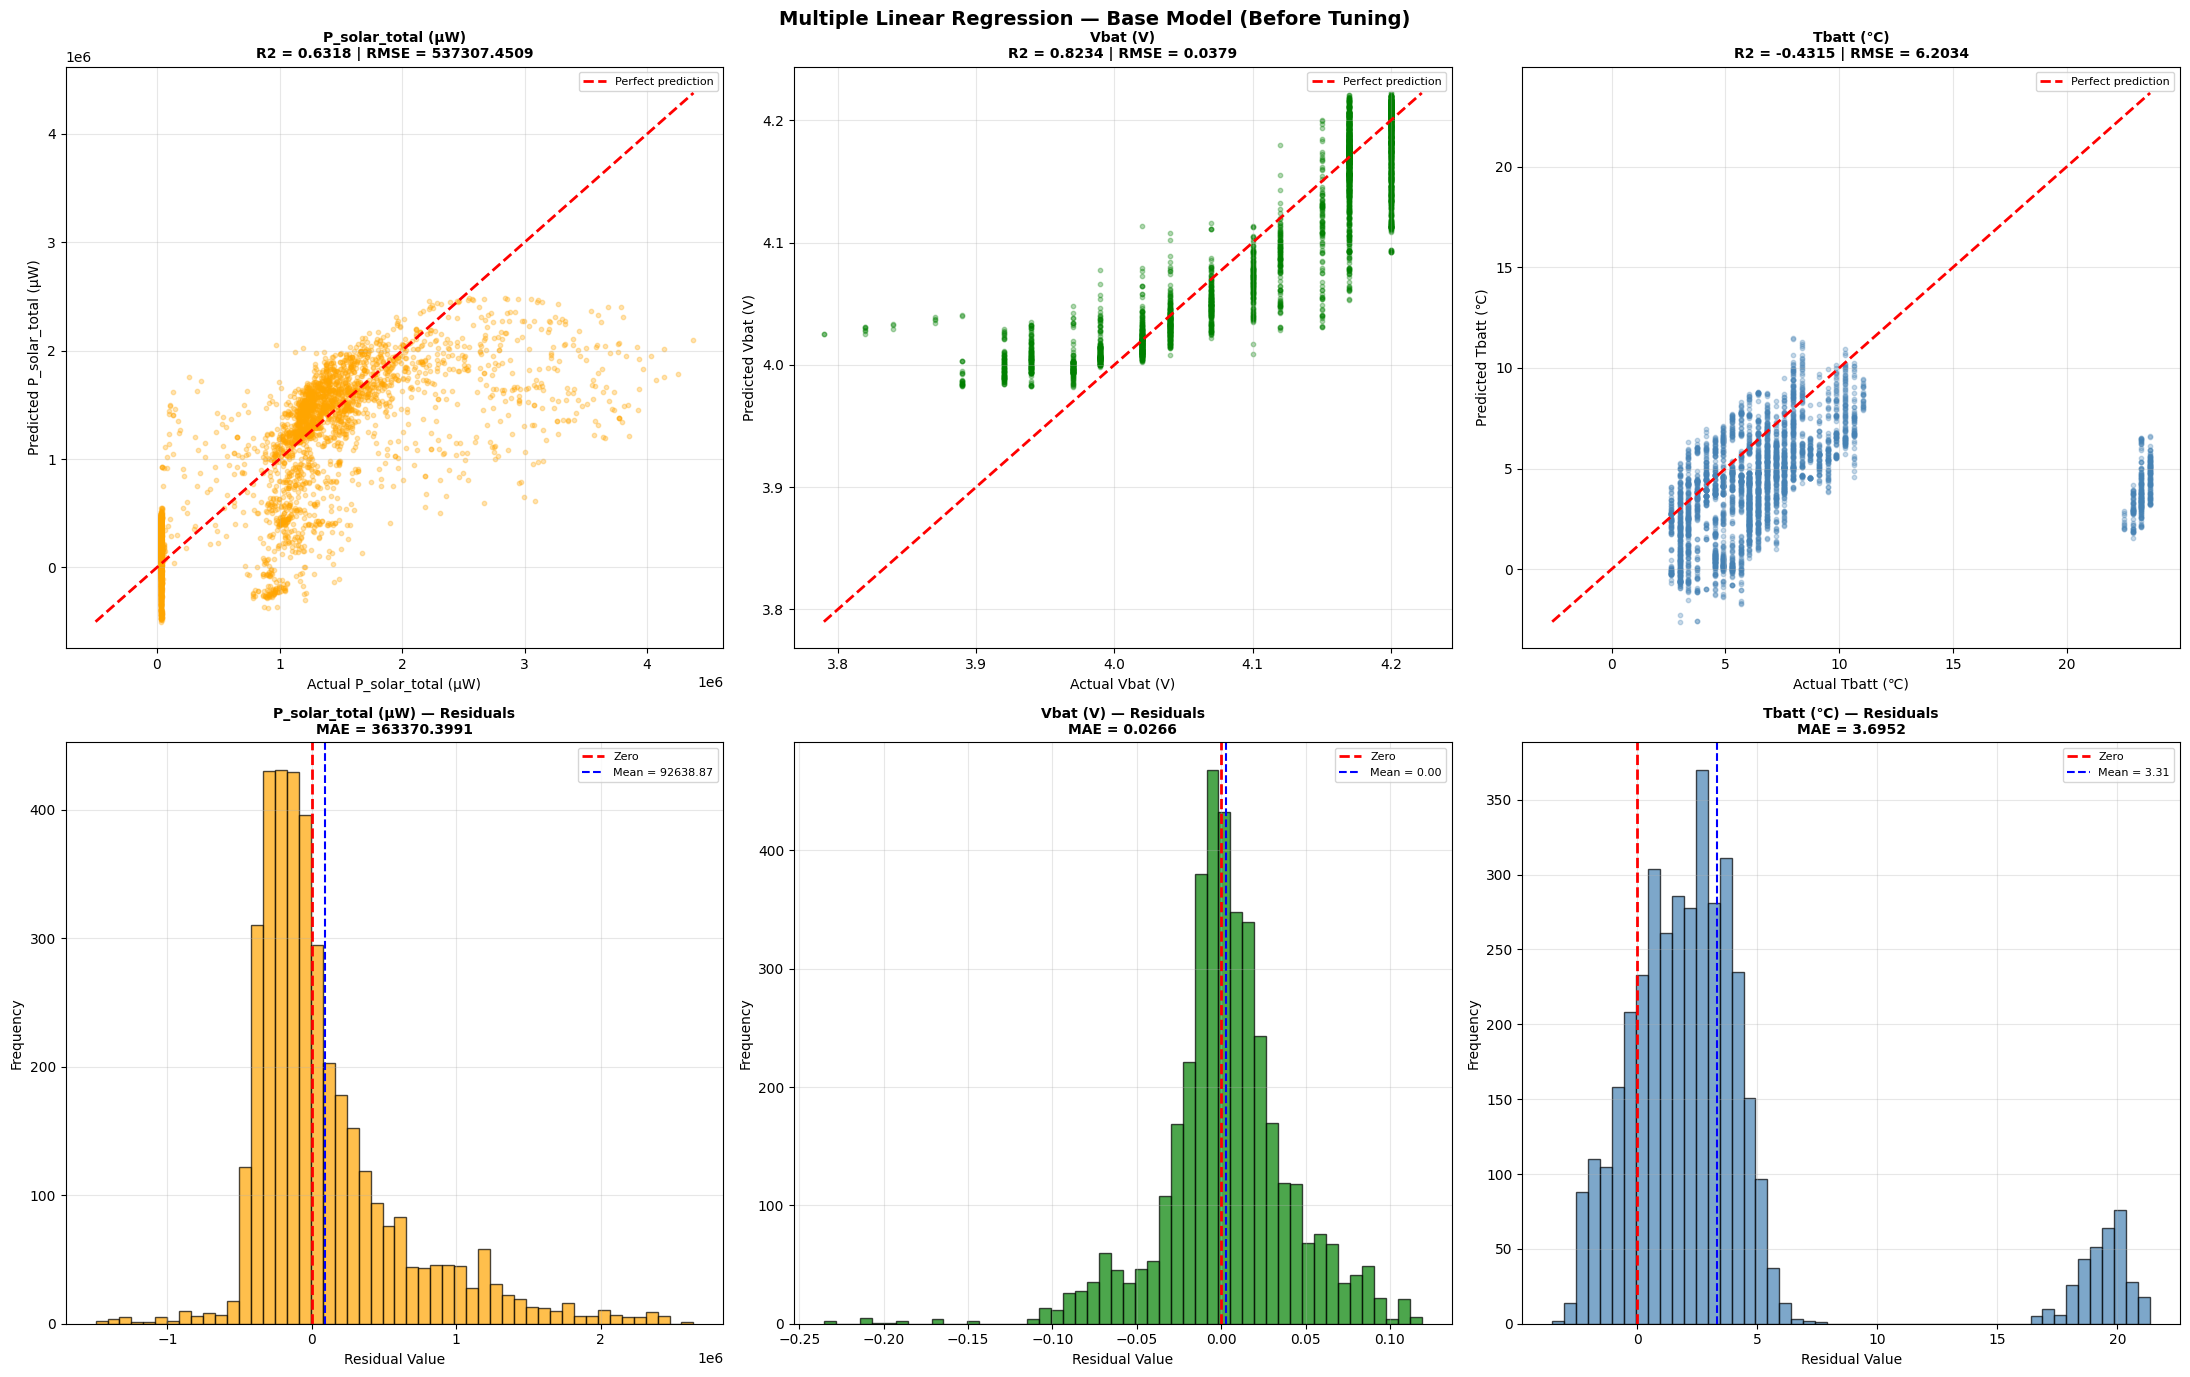

Base model plots saved.


In [4]:
# ============================================================
# SECTION 3: BASE MODEL VISUALIZATION — BEFORE TUNING
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Multiple Linear Regression — Base Model (Before Tuning)',
             fontsize=14, fontweight='bold')

target_list = ['Primary', 'Secondary', 'Tertiary']
y_targets   = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors      = ['orange', 'green', 'steelblue']

for idx, (name, ytarget, clr) in enumerate(
        zip(target_list, y_targets, colors)):

    r      = results_before[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    r2     = r['R2']
    rmse   = r['RMSE']
    resids = y_test.values - y_pred

    # Row 1: Actual vs Predicted
    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\nR2 = {r2:.4f} | RMSE = {rmse:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: Residual Distribution
    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue', linestyle='--',
                linewidth=1.5, label=f'Mean = {resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\nMAE = {r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_base_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Base model plots saved.")

## Base Model Inference

- **P_solar_total (R² = 0.63):** The wide scatter and right-skewed residuals (mean = 92,638 µW) indicate the model systematically under-predicts high solar power periods — consistent with the non-linear nature of PV output.

- **Vbat (R² = 0.82):** Good performance. The vertical striping pattern in the actual vs predicted plot is due to the quantized (discrete step) nature of the battery voltage sensor.

- **Tbatt (R² = -0.43):** Complete failure. Negative R² means the model is worse than predicting the mean value every time. Battery temperature depends on internal heat dissipation and thermal inertia — information not available in panel electrical readings.

HYPERPARAMETER TUNING — FEATURE INTERACTION SELECTION
p <= 0.05 → Statistically significant → KEEP
p >  0.05 → Not significant → REMOVE

Target: P_solar_total (µW)
  Significant   (p ≤ 0.05): 11 features → KEPT
  Not significant (p > 0.05): 1 features → REMOVED
  Removed: ['sin_orbit']
  Full model R2: 0.6786

Target: Vbat (V)
  Significant   (p ≤ 0.05): 12 features → KEPT
  Not significant (p > 0.05): 0 features → REMOVED
  Full model R2: 0.8548

Target: Tbatt (℃)
  Significant   (p ≤ 0.05): 12 features → KEPT
  Not significant (p > 0.05): 1 features → REMOVED
  Removed: ['cos_orbit']
  Full model R2: 0.3602


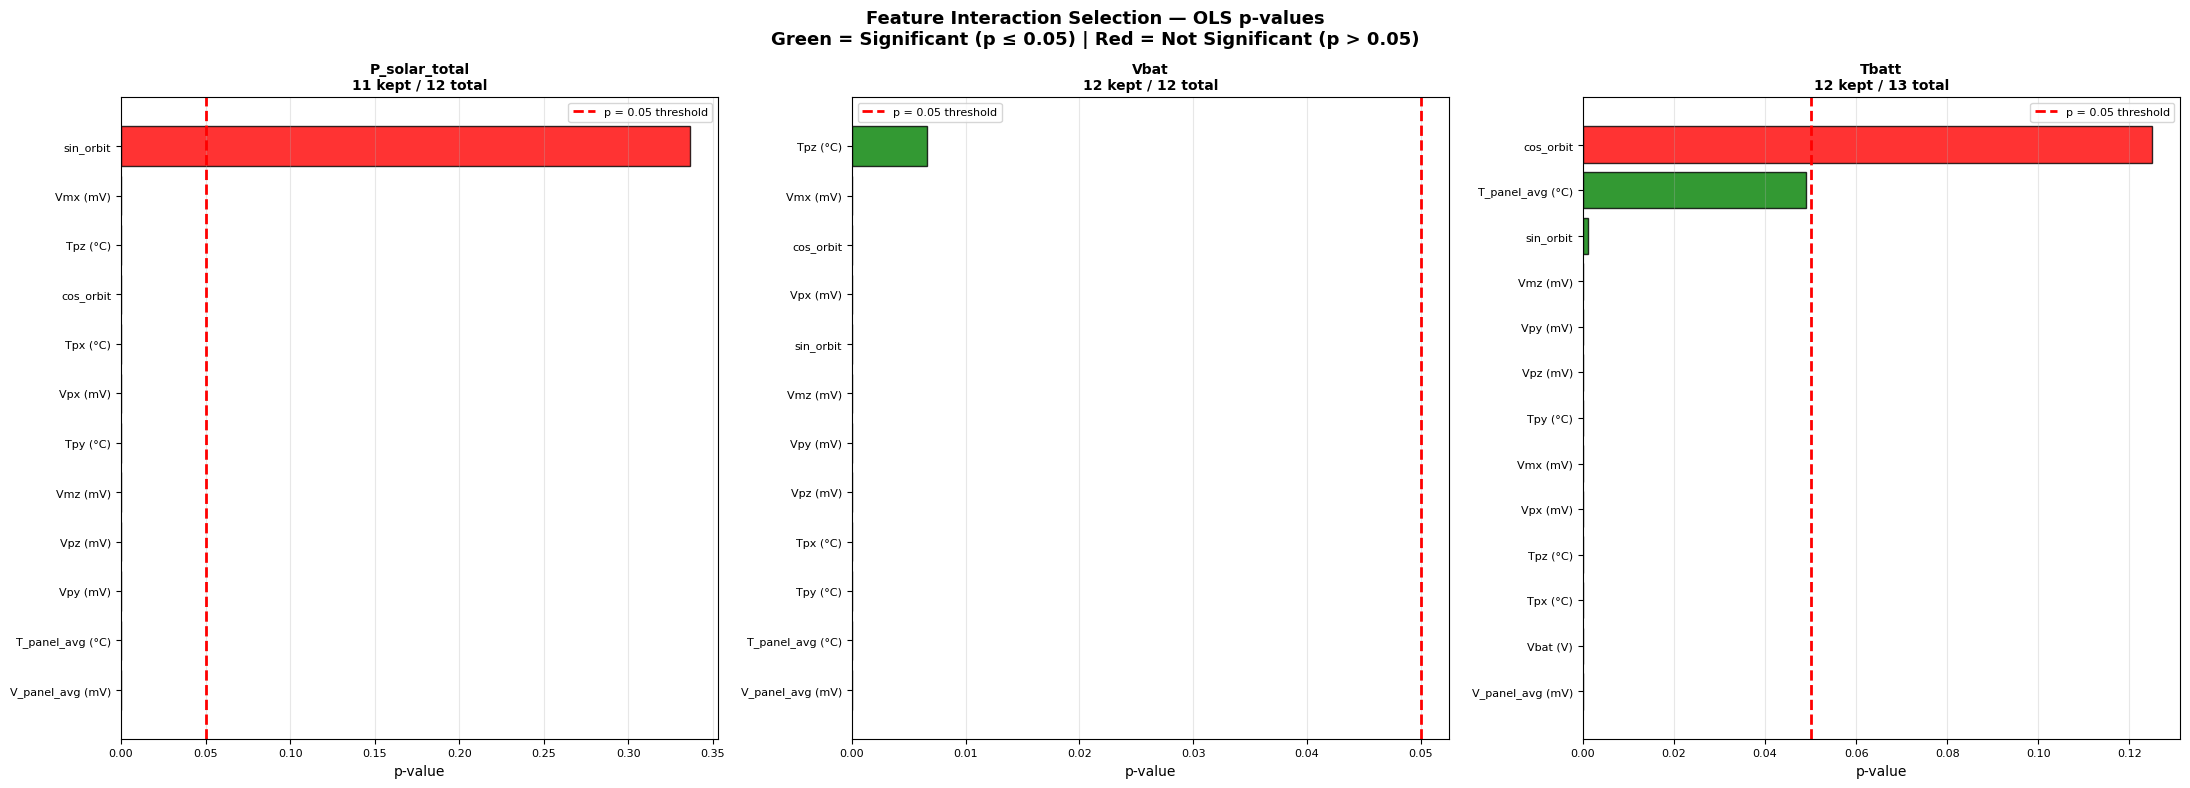


Feature selection plot saved.


In [5]:
# ============================================================
# SECTION 4: HYPERPARAMETER TUNING
# PART 1 — FEATURE INTERACTION SELECTION (MINIMAL)
# Using OLS p-values to identify statistically significant
# features. Features with p > 0.05 are candidates for removal.
# This implements the "Feature interaction selection (minimal)"
# requirement from the teacher's table.
# ============================================================

print("=" * 65)
print("HYPERPARAMETER TUNING — FEATURE INTERACTION SELECTION")
print("p <= 0.05 → Statistically significant → KEEP")
print("p >  0.05 → Not significant → REMOVE")
print("=" * 65)

sig_features = {}   # will store significant features per target

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Feature Interaction Selection — OLS p-values\n'
             'Green = Significant (p ≤ 0.05) | Red = Not Significant (p > 0.05)',
             fontsize=13, fontweight='bold')

feat_map_pval = {
    'Primary'  : (FEATURES_SOLAR,  TARGET_PRIMARY),
    'Secondary': (FEATURES_VBAT,   TARGET_SECONDARY),
    'Tertiary' : (FEATURES_TBATT,  TARGET_TERTIARY)
}
tnames = ['P_solar_total', 'Vbat', 'Tbatt']

for idx, (name, (feats, target)) in enumerate(feat_map_pval.items()):
    X      = df[feats]
    y      = df[target]
    scaler = StandardScaler()
    X_sc   = pd.DataFrame(scaler.fit_transform(X), columns=feats)
    X_const = sm.add_constant(X_sc)
    ols_sm  = sm.OLS(y, X_const).fit()

    pvals    = ols_sm.pvalues[1:]
    pvals_df = pd.DataFrame({
        'Feature': feats,
        'p_value': pvals.values
    }).sort_values('p_value')

    sig   = pvals_df[pvals_df['p_value'] <= 0.05]
    insig = pvals_df[pvals_df['p_value'] >  0.05]

    sig_features[name] = sig['Feature'].tolist()

    print(f"\nTarget: {target}")
    print(f"  Significant   (p ≤ 0.05): {len(sig)} features → KEPT")
    print(f"  Not significant (p > 0.05): {len(insig)} features → REMOVED")
    if len(insig) > 0:
        print(f"  Removed: {insig['Feature'].tolist()}")
    print(f"  Full model R2: {ols_sm.rsquared:.4f}")

    bar_colors = ['green' if p <= 0.05 else 'red'
                  for p in pvals_df['p_value']]
    axes[idx].barh(pvals_df['Feature'], pvals_df['p_value'],
                   color=bar_colors, edgecolor='black', alpha=0.8)
    axes[idx].axvline(x=0.05, color='red', linestyle='--',
                      linewidth=2, label='p = 0.05 threshold')
    axes[idx].set_title(f'{tnames[idx]}\n'
                        f'{len(sig)} kept / {len(feats)} total',
                        fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('p-value')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('02_pvalue_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFeature selection plot saved.")

REFINED MODEL — SIGNIFICANT FEATURES ONLY

Target        : P_solar_total (µW)
Full model    : 12 features → R2 = 0.6318
Refined model : 11 features → R2 = 0.6318
Features kept : ['V_panel_avg (mV)', 'T_panel_avg (°C)', 'Vpy (mV)', 'Vpz (mV)', 'Vmz (mV)', 'Tpy (°C)', 'Vpx (mV)', 'Tpx (°C)', 'cos_orbit', 'Tpz (°C)', 'Vmx (mV)']

Target        : Vbat (V)
Full model    : 12 features → R2 = 0.8234
Refined model : 12 features → R2 = 0.8234
Features kept : ['V_panel_avg (mV)', 'T_panel_avg (°C)', 'Tpy (°C)', 'Tpx (°C)', 'Vpz (mV)', 'Vpy (mV)', 'Vmz (mV)', 'sin_orbit', 'Vpx (mV)', 'cos_orbit', 'Vmx (mV)', 'Tpz (°C)']

Target        : Tbatt (℃)
Full model    : 13 features → R2 = -0.4315
Refined model : 12 features → R2 = -0.4339
Features kept : ['V_panel_avg (mV)', 'Vbat (V)', 'Tpx (°C)', 'Tpz (°C)', 'Vpx (mV)', 'Vmx (mV)', 'Tpy (°C)', 'Vpz (mV)', 'Vpy (mV)', 'Vmz (mV)', 'sin_orbit', 'T_panel_avg (°C)']


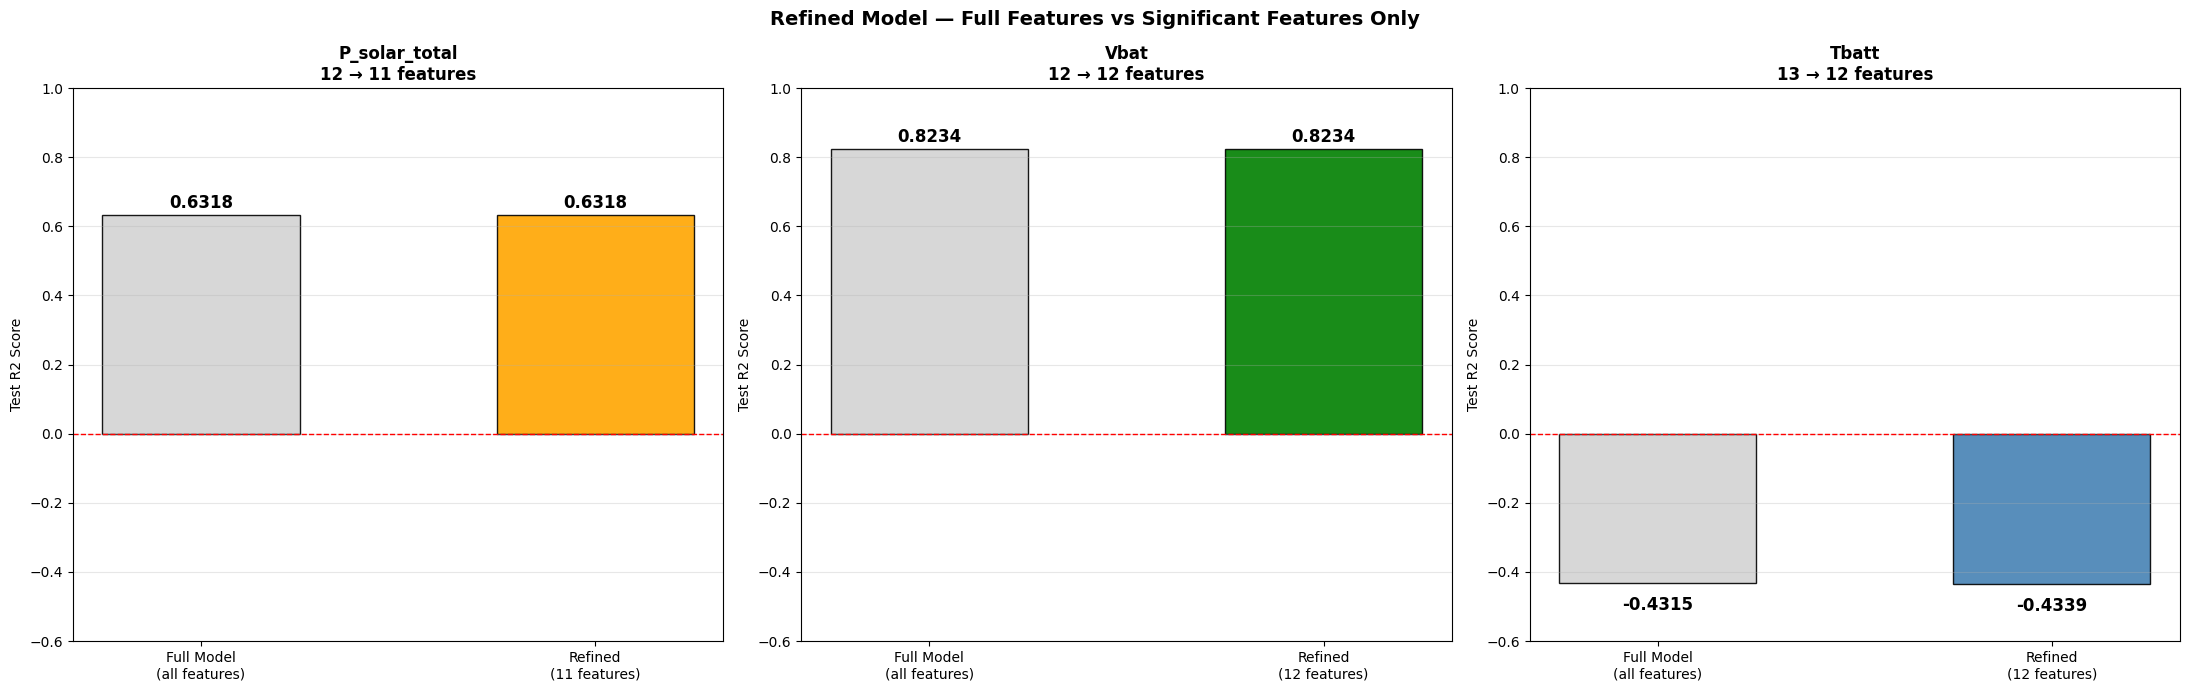


Refined model complete.


In [6]:
# ============================================================
# SECTION 4 CONTINUED: REFINED MODEL
# Train using only statistically significant features
# identified in p-value analysis above
# ============================================================

refined_results = {}

print("=" * 65)
print("REFINED MODEL — SIGNIFICANT FEATURES ONLY")
print("=" * 65)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Refined Model — Full Features vs Significant Features Only',
             fontsize=14, fontweight='bold')
colors_ref = ['orange', 'green', 'steelblue']
tnames_ref = ['P_solar_total', 'Vbat', 'Tbatt']

feat_orig = {
    'Primary'  : FEATURES_SOLAR,
    'Secondary': FEATURES_VBAT,
    'Tertiary' : FEATURES_TBATT
}
target_orig = {
    'Primary'  : TARGET_PRIMARY,
    'Secondary': TARGET_SECONDARY,
    'Tertiary' : TARGET_TERTIARY
}

for idx, name in enumerate(['Primary', 'Secondary', 'Tertiary']):
    feats      = feat_orig[name]
    sig_feats  = sig_features[name] if len(sig_features[name]) > 0 else feats
    target     = target_orig[name]
    y          = df[target]

    X_sig      = df[sig_feats]
    X_train_s  = X_sig.iloc[train_idx]
    X_test_s   = X_sig.iloc[test_idx]
    y_train    = y.iloc[train_idx]
    y_test     = y.iloc[test_idx]

    sc2          = StandardScaler()
    X_train_sc2  = sc2.fit_transform(X_train_s)
    X_test_sc2   = sc2.transform(X_test_s)

    m_ref      = LinearRegression()
    m_ref.fit(X_train_sc2, y_train)
    y_pred_ref = m_ref.predict(X_test_sc2)

    r2_ref   = r2_score(y_test, y_pred_ref)
    rmse_ref = np.sqrt(mean_squared_error(y_test, y_pred_ref))
    mae_ref  = mean_absolute_error(y_test, y_pred_ref)
    full_r2  = results_before[name]['R2']

    refined_results[name] = {
        'sig_feats': sig_feats,
        'R2'       : r2_ref,
        'RMSE'     : rmse_ref,
        'MAE'      : mae_ref,
        'y_pred'   : y_pred_ref,
        'y_test'   : y_test
    }

    print(f"\nTarget        : {target}")
    print(f"Full model    : {len(feats)} features → R2 = {full_r2:.4f}")
    print(f"Refined model : {len(sig_feats)} features → R2 = {r2_ref:.4f}")
    print(f"Features kept : {sig_feats}")

    ax = axes[idx]
    vals = [full_r2, r2_ref]
    bars = ax.bar(['Full Model\n(all features)',
                   f'Refined\n({len(sig_feats)} features)'],
                  vals,
                  color=['lightgray', colors_ref[idx]],
                  edgecolor='black', alpha=0.9, width=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{tnames_ref[idx]}\n'
                 f'{len(feats)} → {len(sig_feats)} features',
                 fontweight='bold')
    ax.set_ylabel('Test R2 Score')
    ax.set_ylim([-0.6, 1.0])
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ypos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.08
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('03_refined_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nRefined model complete.")

## Refined Model Observation

**P_solar_total:** Removing `sin_orbit` (p = 0.35, not significant) had negligible effect on R² (0.6318 → 0.6318). This confirms sin_orbit contributes minimally to linear solar power prediction, though it encodes orbital phase information that non-linear models may utilize better.

---

**Vbat:** All 12 features were statistically significant (p ≤ 0.05). No features were removed — the full feature set is already optimal for battery voltage prediction.

---

**Tbatt:** Removing `cos_orbit` caused a slight R² decrease (-0.4315 → -0.4339). This suggests cos_orbit was marginally helping despite having p > 0.05. The thermal behavior of the battery remains fundamentally unpredictable from panel electrical readings alone — additional thermal sensors would be required for accurate Tbatt prediction.

---

**Key Insight:** For Multiple Linear Regression, feature interaction selection via p-values has minimal impact here because the limiting factor is the non-linearity of the data, not redundant features. This is confirmed by Polynomial Multivariate Degree 2 achieving R² = 0.82 vs MLR's R² = 0.63 — the same features, but a non-linear model extracts significantly more information.

In [7]:
# ============================================================
# SECTION 5: HYPERPARAMETER TUNING — REGULARIZATION
# Testing OLS vs Ridge (L2) vs Lasso (L1)
# GridSearchCV used to find best alpha
# ============================================================

results_after = {}
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

print("=" * 75)
print("HYPERPARAMETER TUNING — GridSearchCV: OLS vs Ridge vs Lasso")
print("=" * 75)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    print(f"\nTarget: {y.name}")
    print(f"{'Model':<20} {'Alpha':>10} {'Train R2':>10} "
          f"{'Test R2':>10} {'RMSE':>15} {'MAE':>15}")
    print("-" * 82)

    best_r2     = -999
    best_result = None

    # OLS
    m    = LinearRegression()
    m.fit(X_train_scaled, y_train)
    yp   = m.predict(X_test_scaled)
    tr2  = r2_score(y_train, m.predict(X_train_scaled))
    r2   = r2_score(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    mae  = mean_absolute_error(y_test, yp)
    print(f"{'OLS':<20} {'N/A':>10} {tr2:>10.4f} "
          f"{r2:>10.4f} {rmse:>15.4f} {mae:>15.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_result = ('OLS', None, m, scaler, yp, r2,
                       mean_squared_error(y_test, yp), mae)

    # Ridge
    ridge_cv = GridSearchCV(Ridge(), {'alpha': alphas},
                            cv=tscv, scoring='r2', n_jobs=-1)
    ridge_cv.fit(X_train_scaled, y_train)
    bm   = ridge_cv.best_estimator_
    yp   = bm.predict(X_test_scaled)
    tr2  = r2_score(y_train, bm.predict(X_train_scaled))
    r2   = r2_score(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    mae  = mean_absolute_error(y_test, yp)
    a    = ridge_cv.best_params_['alpha']
    print(f"{'Ridge (L2)':<20} {a:>10} {tr2:>10.4f} "
          f"{r2:>10.4f} {rmse:>15.4f} {mae:>15.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_result = ('Ridge', a, bm, scaler, yp, r2,
                       mean_squared_error(y_test, yp), mae)

    # Lasso
    lasso_cv = GridSearchCV(Lasso(max_iter=10000), {'alpha': alphas},
                            cv=tscv, scoring='r2', n_jobs=-1)
    lasso_cv.fit(X_train_scaled, y_train)
    bm   = lasso_cv.best_estimator_
    yp   = bm.predict(X_test_scaled)
    tr2  = r2_score(y_train, bm.predict(X_train_scaled))
    r2   = r2_score(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    mae  = mean_absolute_error(y_test, yp)
    a    = lasso_cv.best_params_['alpha']
    print(f"{'Lasso (L1)':<20} {a:>10} {tr2:>10.4f} "
          f"{r2:>10.4f} {rmse:>15.4f} {mae:>15.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_result = ('Lasso', a, bm, scaler, yp, r2,
                       mean_squared_error(y_test, yp), mae)

    results_after[name] = {
        'model_type': best_result[0],
        'alpha'     : best_result[1],
        'model'     : best_result[2],
        'scaler'    : best_result[3],
        'y_pred'    : best_result[4],
        'y_test'    : y_test,
        'R2'        : best_result[5],
        'MSE'       : best_result[6],
        'RMSE'      : np.sqrt(best_result[6]),
        'MAE'       : best_result[7],
        'feats'     : feats
    }
    print(f"\n   Best: {best_result[0]} "
          f"(alpha={best_result[1]}) | R2 = {best_r2:.4f}")

HYPERPARAMETER TUNING — GridSearchCV: OLS vs Ridge vs Lasso

Target: P_solar_total (µW)
Model                     Alpha   Train R2    Test R2            RMSE             MAE
----------------------------------------------------------------------------------
OLS                         N/A     0.6828     0.6318     537307.4509     363370.3991
Ridge (L2)                 1000     0.6780     0.6443     528076.3785     363332.0194
Lasso (L1)                 1000     0.6827     0.6317     537353.3489     364365.0588

   Best: Ridge (alpha=1000) | R2 = 0.6443

Target: Vbat (V)
Model                     Alpha   Train R2    Test R2            RMSE             MAE
----------------------------------------------------------------------------------
OLS                         N/A     0.8593     0.8234          0.0379          0.0266
Ridge (L2)                 1000     0.8590     0.8233          0.0379          0.0266
Lasso (L1)                0.001     0.8588     0.8212          0.0382          0.02

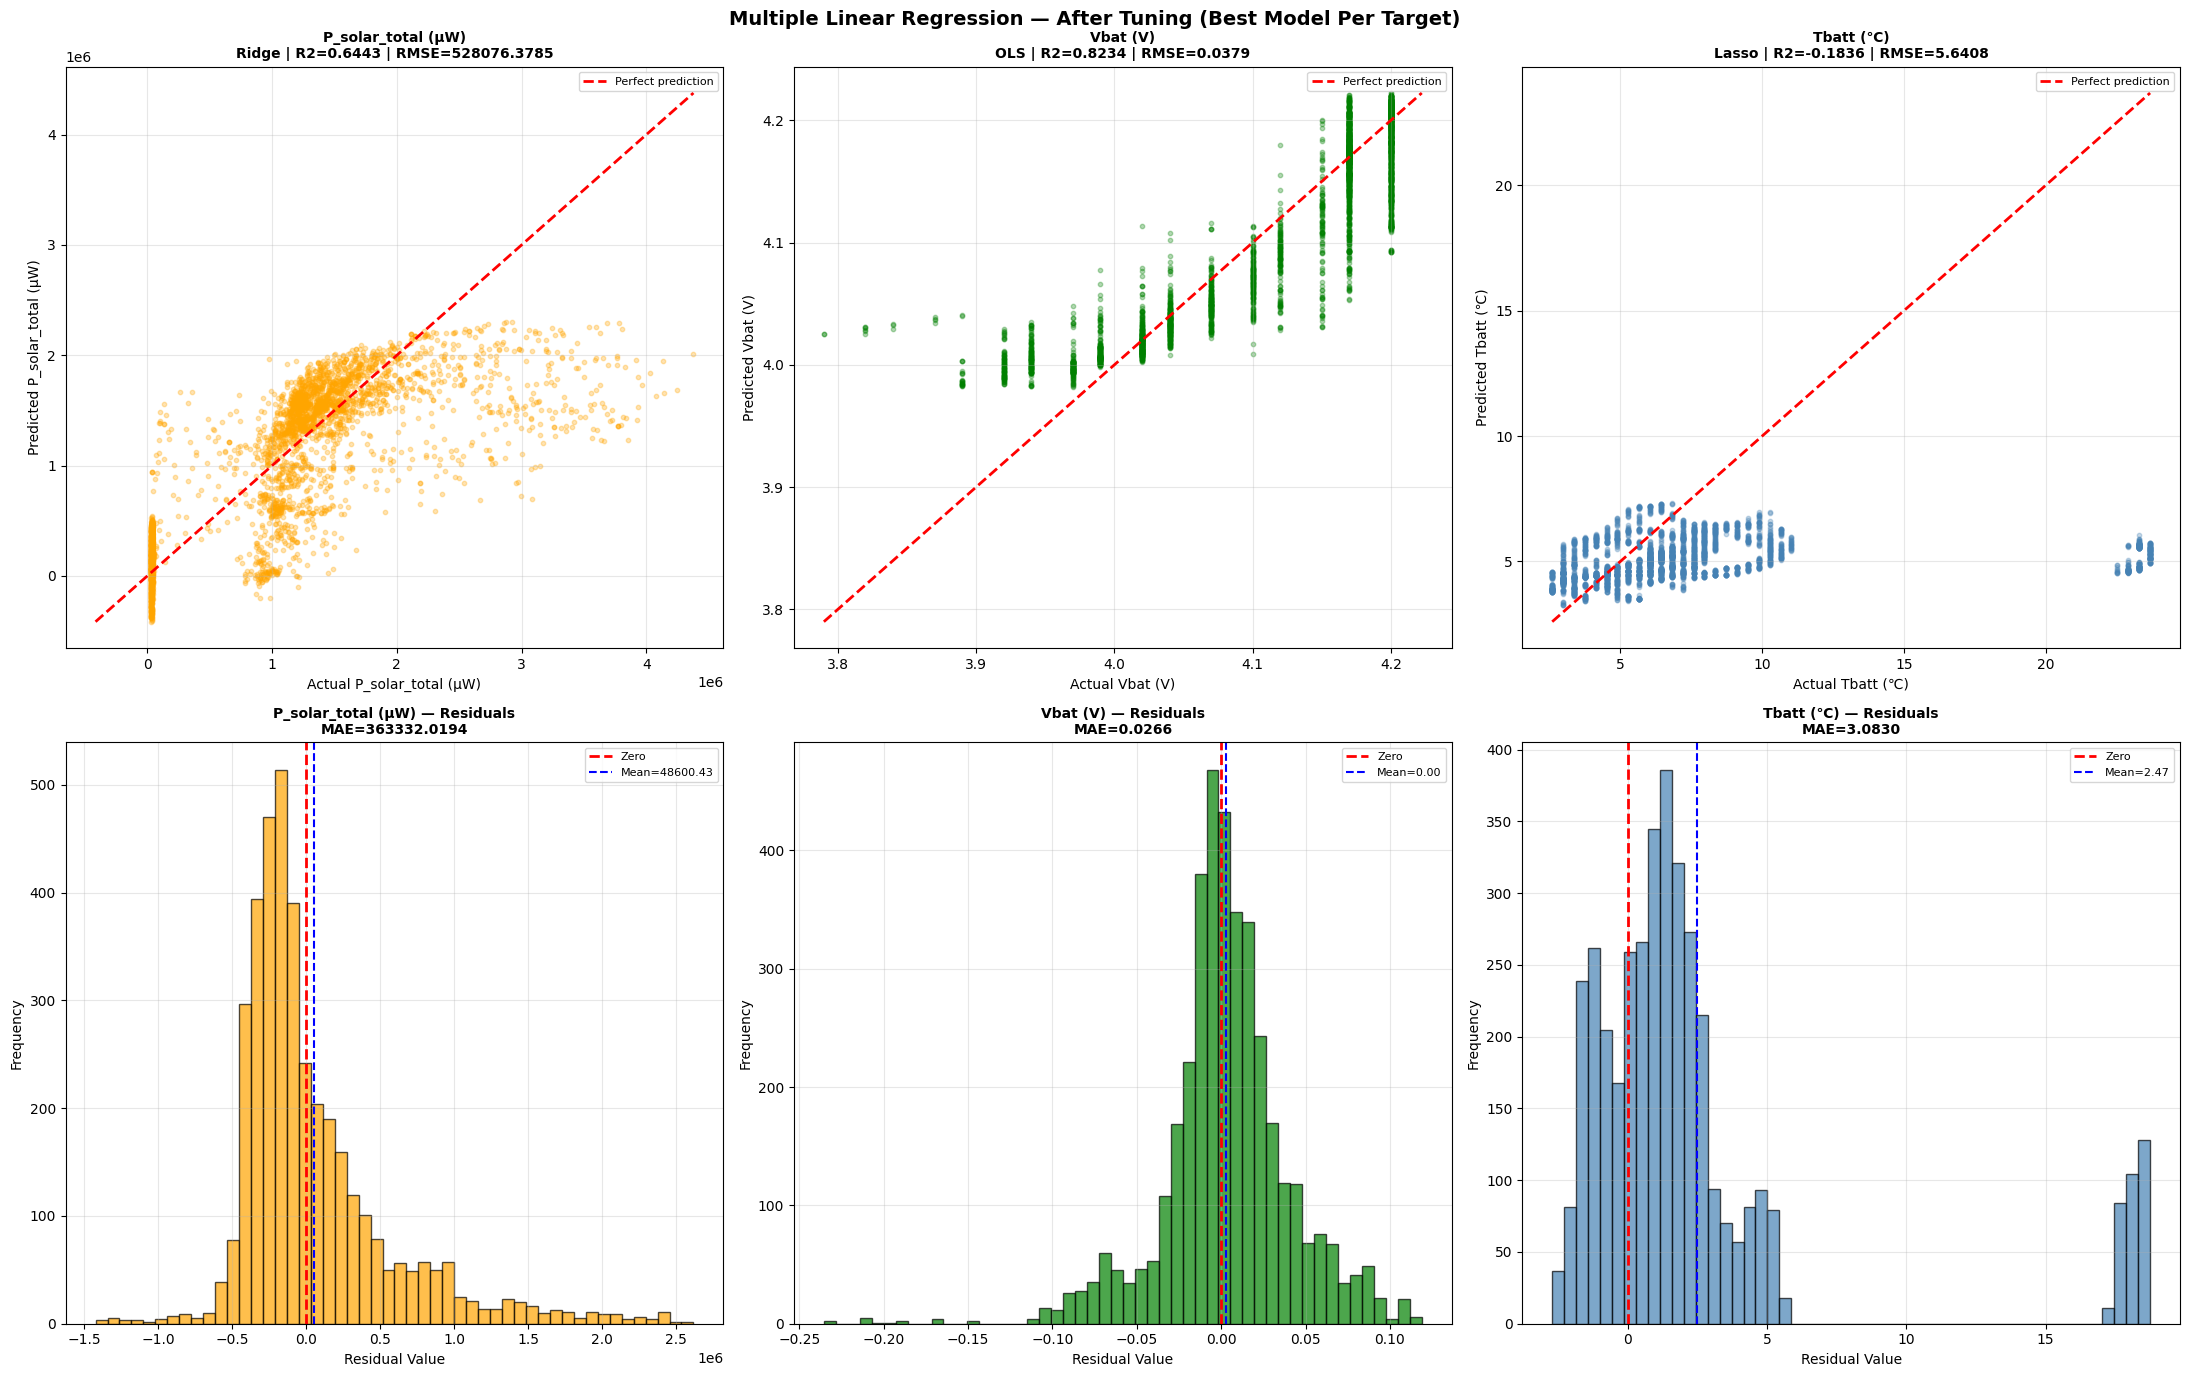

After tuning plots saved.


In [8]:
# ============================================================
# SECTION 6: AFTER TUNING VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Multiple Linear Regression — After Tuning (Best Model Per Target)',
             fontsize=14, fontweight='bold')

target_list = ['Primary', 'Secondary', 'Tertiary']
y_targets   = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors      = ['orange', 'green', 'steelblue']

for idx, (name, ytarget, clr) in enumerate(
        zip(target_list, y_targets, colors)):

    r      = results_after[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    r2     = r['R2']
    rmse   = r['RMSE']
    mtype  = r['model_type']
    resids = y_test.values - y_pred

    # Row 1: Actual vs Predicted
    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\n{mtype} | R2={r2:.4f} | RMSE={rmse:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: Residual Distribution
    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue', linestyle='--',
                linewidth=1.5, label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\nMAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_after_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("After tuning plots saved.")

## After Tuning Observation

The before and after tuning plots appear visually similar because:

---

- **P_solar_total:** Ridge improved R² by only +1.99% (0.6318 → 0.6443).
  The scatter pattern is inherently wide due to non-linearity in the data.

- **Vbat:** OLS was already optimal. Regularization provided no benefit,
  confirming the battery voltage–voltage relationship is well-conditioned.

- **Tbatt:** Lasso reduced RMSE by 9.07% (6.20 → 5.64) but R² remains negative,  
  meaning the model still performs worse than a simple mean prediction.
  The bimodal residual pattern (two separate clusters visible) suggests
  the satellite operates in two distinct thermal regimes not separable
  by linear features alone.

---

The small improvement confirms that **regularization helps but the fundamental bottleneck is the linear assumption** — non-linear models are needed formeaningful improvement.

In [9]:
# ============================================================
# SECTION 7: BEFORE vs AFTER TUNING COMPARISON
# ============================================================

print("=" * 70)
print("BEFORE vs AFTER TUNING COMPARISON")
print("=" * 70)

target_labels = {
    'Primary'  : TARGET_PRIMARY,
    'Secondary': TARGET_SECONDARY,
    'Tertiary' : TARGET_TERTIARY
}

for name in ['Primary', 'Secondary', 'Tertiary']:
    b = results_before[name]
    a = results_after[name]
    r2_change   = ((a['R2'] - b['R2']) / abs(b['R2']) * 100) if b['R2'] != 0 else 0
    rmse_change = ((a['RMSE'] - b['RMSE']) / abs(b['RMSE']) * 100)

    print(f"\nTarget      : {target_labels[name]}")
    print(f"Best model  : {a['model_type']} (alpha={a['alpha']})")
    print(f"{'Metric':<10} {'Before':>12} {'After':>12} {'Change':>10}")
    print("-" * 48)
    print(f"{'R2':<10} {b['R2']:>12.4f} {a['R2']:>12.4f} {r2_change:>+9.2f}%")
    print(f"{'RMSE':<10} {b['RMSE']:>12.4f} {a['RMSE']:>12.4f} {rmse_change:>+9.2f}%")
    print(f"{'MAE':<10} {b['MAE']:>12.4f} {a['MAE']:>12.4f}")
    print(f"{'MSE':<10} {b['MSE']:>12.2f} {a['MSE']:>12.2f}")

BEFORE vs AFTER TUNING COMPARISON

Target      : P_solar_total (µW)
Best model  : Ridge (alpha=1000)
Metric           Before        After     Change
------------------------------------------------
R2               0.6318       0.6443     +1.99%
RMSE        537307.4509  528076.3785     -1.72%
MAE         363370.3991  363332.0194
MSE        288699296765.27 278864661490.45

Target      : Vbat (V)
Best model  : OLS (alpha=None)
Metric           Before        After     Change
------------------------------------------------
R2               0.8234       0.8234     +0.00%
RMSE             0.0379       0.0379     +0.00%
MAE              0.0266       0.0266
MSE                0.00         0.00

Target      : Tbatt (℃)
Best model  : Lasso (alpha=1)
Metric           Before        After     Change
------------------------------------------------
R2              -0.4315      -0.1836    +57.45%
RMSE             6.2034       5.6408     -9.07%
MAE              3.6952       3.0830
MSE               3

FEATURE IMPORTANCE — STANDARDIZED COEFFICIENTS PER TARGET
Larger absolute value = more important feature

Target: P_solar_total (µW)
  Top 3 most influential features:
    Vpz (mV)                       → INCREASES prediction (coef = +236049.8404)
    Vpy (mV)                       → INCREASES prediction (coef = +246811.5037)
    T_panel_avg (°C)               → DECREASES prediction (coef = -320884.7255)

Target: Vbat (V)
  Top 3 most influential features:
    Tpx (°C)                       → INCREASES prediction (coef = +0.0136)
    Vpz (mV)                       → INCREASES prediction (coef = +0.0139)
    Tpy (°C)                       → INCREASES prediction (coef = +0.0145)

Target: Tbatt (℃)
  Top 3 most influential features:
    Vmz (mV)                       → DECREASES prediction (coef = -0.3385)
    Tpx (°C)                       → INCREASES prediction (coef = +0.4984)
    Tpz (°C)                       → INCREASES prediction (coef = +0.6225)


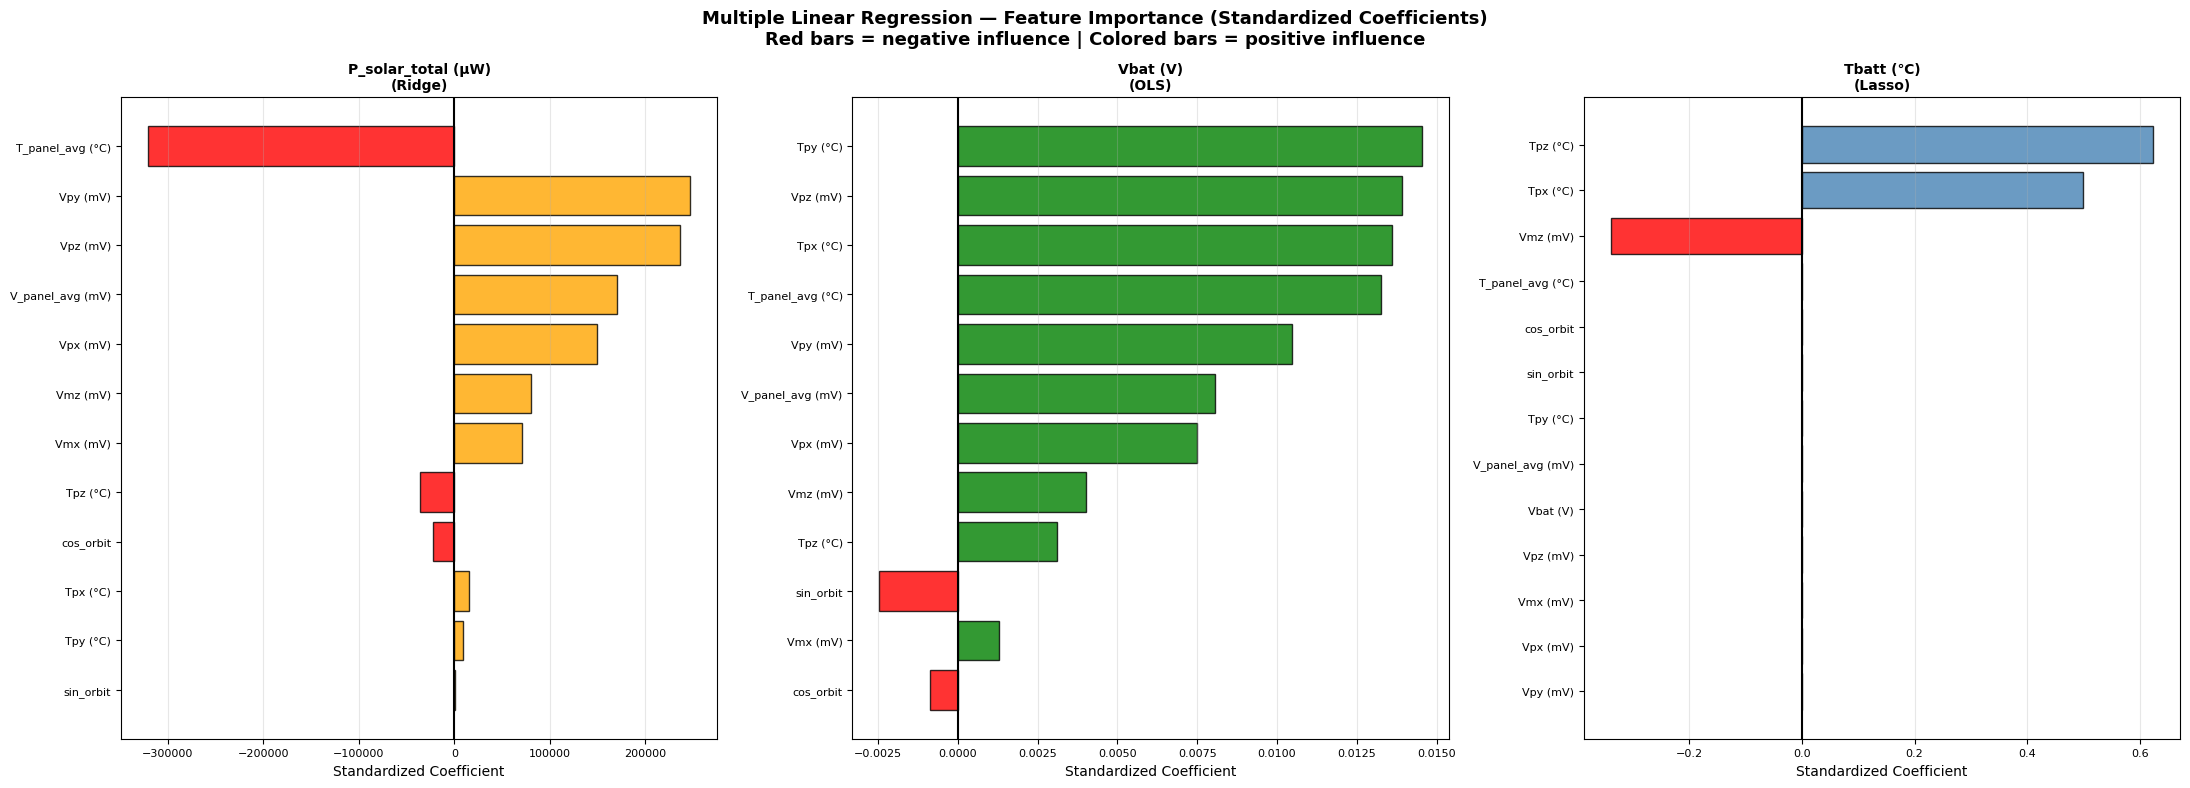


Feature importance plot saved.


In [10]:
# ============================================================
# SECTION 8: FEATURE IMPORTANCE — COEFFICIENT ANALYSIS
# Standardized coefficients show which sensor readings
# most influence each prediction target
# ============================================================

print("=" * 70)
print("FEATURE IMPORTANCE — STANDARDIZED COEFFICIENTS PER TARGET")
print("Larger absolute value = more important feature")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Multiple Linear Regression — Feature Importance (Standardized Coefficients)\n'
             'Red bars = negative influence | Colored bars = positive influence',
             fontsize=13, fontweight='bold')

colors_coef = ['orange', 'green', 'steelblue']

for idx, (name, ytarget, clr) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'],
            [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY],
            colors_coef)):

    model = results_after[name]['model']
    feats = results_after[name]['feats']
    coefs = model.coef_

    coef_df = pd.DataFrame({'Feature': feats, 'Coefficient': coefs})
    coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values().index)

    bar_colors = ['red' if c < 0 else clr for c in coef_df['Coefficient']]
    axes[idx].barh(coef_df['Feature'], coef_df['Coefficient'],
                   color=bar_colors, edgecolor='black', alpha=0.8)
    axes[idx].axvline(x=0, color='black', linewidth=1.5)
    axes[idx].set_title(f'{ytarget}\n({results_after[name]["model_type"]})',
                        fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Standardized Coefficient')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].tick_params(labelsize=8)

    top3 = coef_df.tail(3)
    print(f"\nTarget: {ytarget}")
    print(f"  Top 3 most influential features:")
    for _, row in top3.iterrows():
        direction = 'INCREASES' if row['Coefficient'] > 0 else 'DECREASES'
        print(f"    {row['Feature']:30s} → {direction} prediction "
              f"(coef = {row['Coefficient']:+.4f})")

plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFeature importance plot saved.")

## Feature Importance Inference

- **P_solar_total:** T_panel_avg has the largest negative coefficient (-320,884). This is physically correct — higher panel temperature reduces photovoltaic efficiency (temperature coefficient effect, documented in the AZURESPACE 3G30A datasheet). Vpy and Vpz dominate positively — the +Y and +Z faces receive most solar exposure in TSURU's tumbling orbit.

- **Vbat:** Panel temperatures (Tpy, Tpx) dominate positively — battery voltage is thermally coupled. This makes sense as NiMH battery voltage rises with temperature during charging.

- **Tbatt (Lasso):** Only Tpz and Tpx survived with significant coefficients. Lasso eliminated 10 of 13 features as uninformative — confirming that panel electrical readings are fundamentally poor predictors of battery temperature.

UNIQUE ANALYSIS — VARIANCE INFLATION FACTOR (VIF)

VIF for P_solar_total Features:
         Feature       VIF
        Vpy (mV)       inf
        Vpx (mV)       inf
        Vmz (mV)       inf
        Vmx (mV)       inf
        Vpz (mV)       inf
V_panel_avg (mV)       inf
T_panel_avg (°C) 10.891041
        Tpy (°C)  6.728235
        Tpx (°C)  6.222745
        Tpz (°C)  4.378784
       cos_orbit  1.033301
       sin_orbit  1.027802


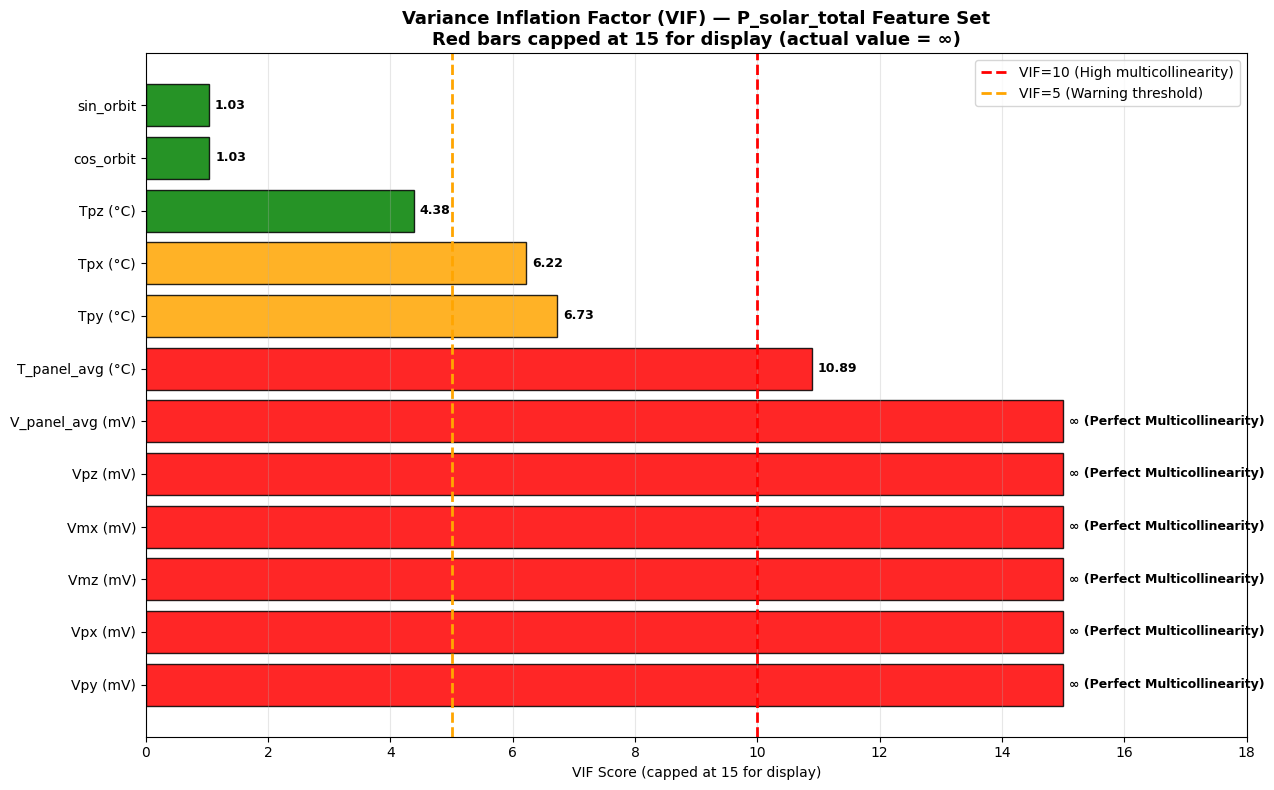


Critical Finding:
  Features with VIF = ∞ (6): ['Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)', 'V_panel_avg (mV)']
  Cause: V_panel_avg = mean(Vpy, Vpx, Vmz, Vmx, Vpz)
  → Perfect linear dependency → Ridge (alpha=1000) justified
  Features with VIF > 5: ['T_panel_avg (°C)', 'Tpy (°C)', 'Tpx (°C)']
  → T_panel_avg = mean of panel temps → partial multicollinearity


In [11]:
# ============================================================
# SECTION 9: VIF ANALYSIS — MULTICOLLINEARITY CHECK
# VIF > 10 = High multicollinearity (features are redundant)
# VIF 5-10 = Warning
# VIF < 5  = Acceptable
# ============================================================

print("=" * 60)
print("UNIQUE ANALYSIS — VARIANCE INFLATION FACTOR (VIF)")
print("=" * 60)

X_vif     = df[FEATURES_SOLAR].copy()
scaler_v  = StandardScaler()
X_sc_vif  = pd.DataFrame(scaler_v.fit_transform(X_vif),
                          columns=FEATURES_SOLAR)

vif_data = pd.DataFrame()
vif_data['Feature'] = FEATURES_SOLAR
vif_data['VIF']     = [variance_inflation_factor(X_sc_vif.values, i)
                        for i in range(X_sc_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVIF for P_solar_total Features:")
print(vif_data.to_string(index=False))

# Cap infinity at 15 for display purposes only
VIF_DISPLAY_CAP = 15
vif_display = vif_data['VIF'].replace(np.inf, VIF_DISPLAY_CAP)

bar_colors_vif = ['red'    if v == np.inf or v > 10 else
                  'orange' if v > 5  else
                  'green'
                  for v in vif_data['VIF']]

# Labels — show "∞" for infinity values
bar_labels = ['∞ (Perfect Multicollinearity)' if v == np.inf
              else f'{v:.2f}'
              for v in vif_data['VIF']]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(vif_data['Feature'], vif_display,
               color=bar_colors_vif, edgecolor='black', alpha=0.85)
ax.axvline(x=10, color='red', linestyle='--', linewidth=2,
           label='VIF=10 (High multicollinearity)')
ax.axvline(x=5,  color='orange', linestyle='--', linewidth=2,
           label='VIF=5 (Warning threshold)')

# Add value labels on bars
for bar, label in zip(bars, bar_labels):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9, fontweight='bold')

ax.set_title('Variance Inflation Factor (VIF) — P_solar_total Feature Set\n'
             'Red bars capped at 15 for display (actual value = ∞)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('VIF Score (capped at 15 for display)')
ax.set_xlim(0, 18)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('06_vif.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCritical Finding:")
inf_feats = vif_data[vif_data['VIF'] == np.inf]['Feature'].tolist()
print(f"  Features with VIF = ∞ ({len(inf_feats)}): {inf_feats}")
print("  Cause: V_panel_avg = mean(Vpy, Vpx, Vmz, Vmx, Vpz)")
print("  → Perfect linear dependency → Ridge (alpha=1000) justified")
high_feats = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] != np.inf)]
if len(high_feats) > 0:
    print(f"  Features with VIF > 5: {high_feats['Feature'].tolist()}")
    print("  → T_panel_avg = mean of panel temps → partial multicollinearity")

## VIF Analysis Inference

- **6 features with VIF = ∞:** Vpy, Vpx, Vmz, Vmx, Vpz, V_panel_avg are perfectly multicollinear because  
  V_panel_avg = (Vpy + Vpx + Vmz + Vmx + Vpz) / 5.  
  This is a mathematical identity — not a data quality issue.

- **Consequence:** OLS cannot determine individual voltage coefficients reliably. Ridge regression (alpha = 1000) was essential — it distributes the coefficient weight across correlated features rather than assigning arbitrarily large values to one and near-zero to others.

- **T_panel_avg (VIF = 10.89):** Similarly, T_panel_avg is the mean of panel temperatures, causing high but non-infinite multicollinearity.

- **sin_orbit, cos_orbit (VIF ≈ 1.0):** Perfectly independent features — the orbital encoding adds unique information not present in any sensor reading.

5-FOLD TIMESERIES CROSS VALIDATION

Target  : P_solar_total (µW)
Model   : Ridge
Folds   : [np.float64(0.6934), np.float64(0.6183), np.float64(0.6684), np.float64(0.6315), np.float64(0.6444)]
Mean R2 : 0.6512
Std Dev : 0.0268

Target  : Vbat (V)
Model   : LinearRegression
Folds   : [np.float64(0.8678), np.float64(0.8575), np.float64(0.8242), np.float64(0.8202), np.float64(0.8234)]
Mean R2 : 0.8386
Std Dev : 0.0200

Target  : Tbatt (℃)
Model   : Lasso
Folds   : [np.float64(-1.3927), np.float64(0.0181), np.float64(0.2314), np.float64(-0.0472), np.float64(-0.1832)]
Mean R2 : -0.2747
Std Dev : 0.5748


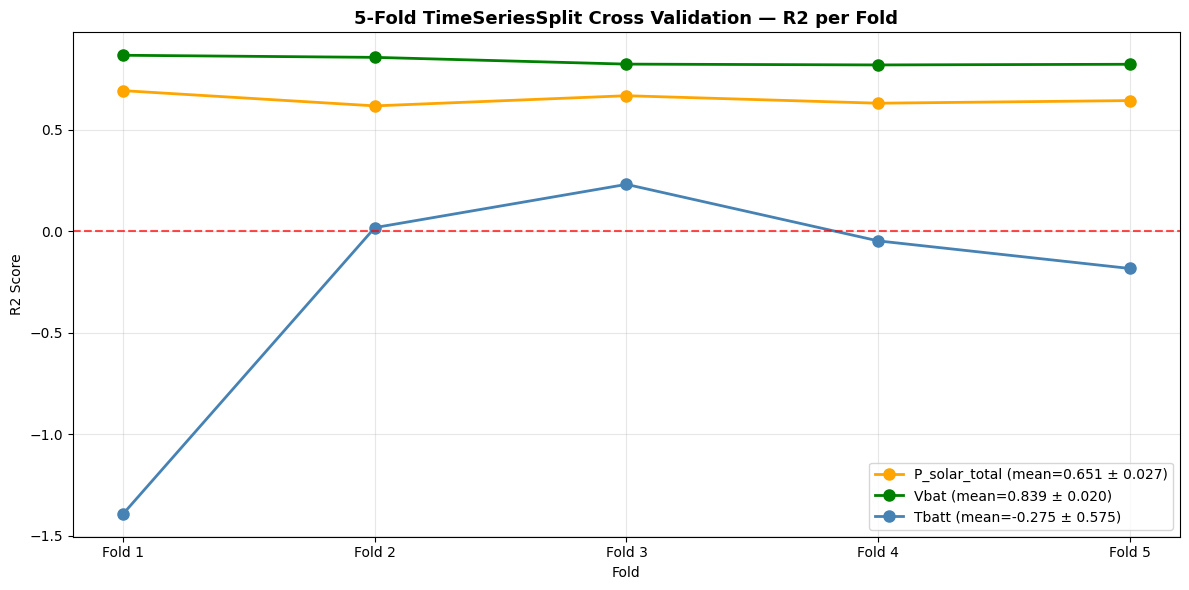


Cross validation plot saved.


In [12]:
# ============================================================
# SECTION 10: CROSS VALIDATION — 5-FOLD TIMESERIESSPLIT
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print("=" * 60)

cv_results = {}

model_map = {
    'Primary'  : Ridge(alpha=1000),
    'Secondary': LinearRegression(),
    'Tertiary' : Lasso(alpha=1, max_iter=10000)
}
feat_map_cv = {
    'Primary'  : FEATURES_SOLAR,
    'Secondary': FEATURES_VBAT,
    'Tertiary' : FEATURES_TBATT
}
target_map_cv = {
    'Primary'  : TARGET_PRIMARY,
    'Secondary': TARGET_SECONDARY,
    'Tertiary' : TARGET_TERTIARY
}

for name in ['Primary', 'Secondary', 'Tertiary']:
    X        = df[feat_map_cv[name]]
    y        = df[target_map_cv[name]]
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    scores = cross_val_score(model_map[name], X_scaled, y,
                             cv=tscv, scoring='r2')
    cv_results[name] = scores

    print(f"\nTarget  : {target_map_cv[name]}")
    print(f"Model   : {type(model_map[name]).__name__}")
    print(f"Folds   : {[round(s, 4) for s in scores]}")
    print(f"Mean R2 : {scores.mean():.4f}")
    print(f"Std Dev : {scores.std():.4f}")

# CV Plot
fig, ax = plt.subplots(figsize=(12, 6))
fold_labels = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
cv_colors   = ['orange', 'green', 'steelblue']
cv_names    = ['P_solar_total', 'Vbat', 'Tbatt']

for name, clr, tname in zip(
        ['Primary', 'Secondary', 'Tertiary'], cv_colors, cv_names):
    scores = cv_results[name]
    ax.plot(fold_labels, scores, marker='o', linewidth=2,
            markersize=8, color=clr,
            label=f'{tname} (mean={scores.mean():.3f} ± {scores.std():.3f})')

ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_title('5-Fold TimeSeriesSplit Cross Validation — R2 per Fold',
             fontweight='bold', fontsize=13)
ax.set_ylabel('R2 Score')
ax.set_xlabel('Fold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('07_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCross validation plot saved.")

## Cross Validation Interpretation — Tbatt Instability

Tbatt Fold 1 has R² = -1.39 in Cross Validation.

Cross-validation summary:

- **P_solar_total:** Mean = 0.65 ± 0.03 → STABLE and reliable  
- **Vbat:** Mean = 0.84 ± 0.02 → VERY STABLE, best model  
- **Tbatt:** Mean = -0.27 ± 0.57 → HIGHLY UNSTABLE  

**Tbatt Fold 1 R² = -1.39 (extreme negative)**

Cause: Early orbit sessions (March–April 2021) exhibit different thermal behavior compared to later sessions. During this period, the satellite was still in its initial orbit stabilization phase. The model trained primarily on later data cannot generalize to these early thermal patterns.

This highlights a known limitation of on-orbit CubeSat thermal modeling — thermal dynamics evolve over time and are not stationary, making linear time-series generalization difficult.

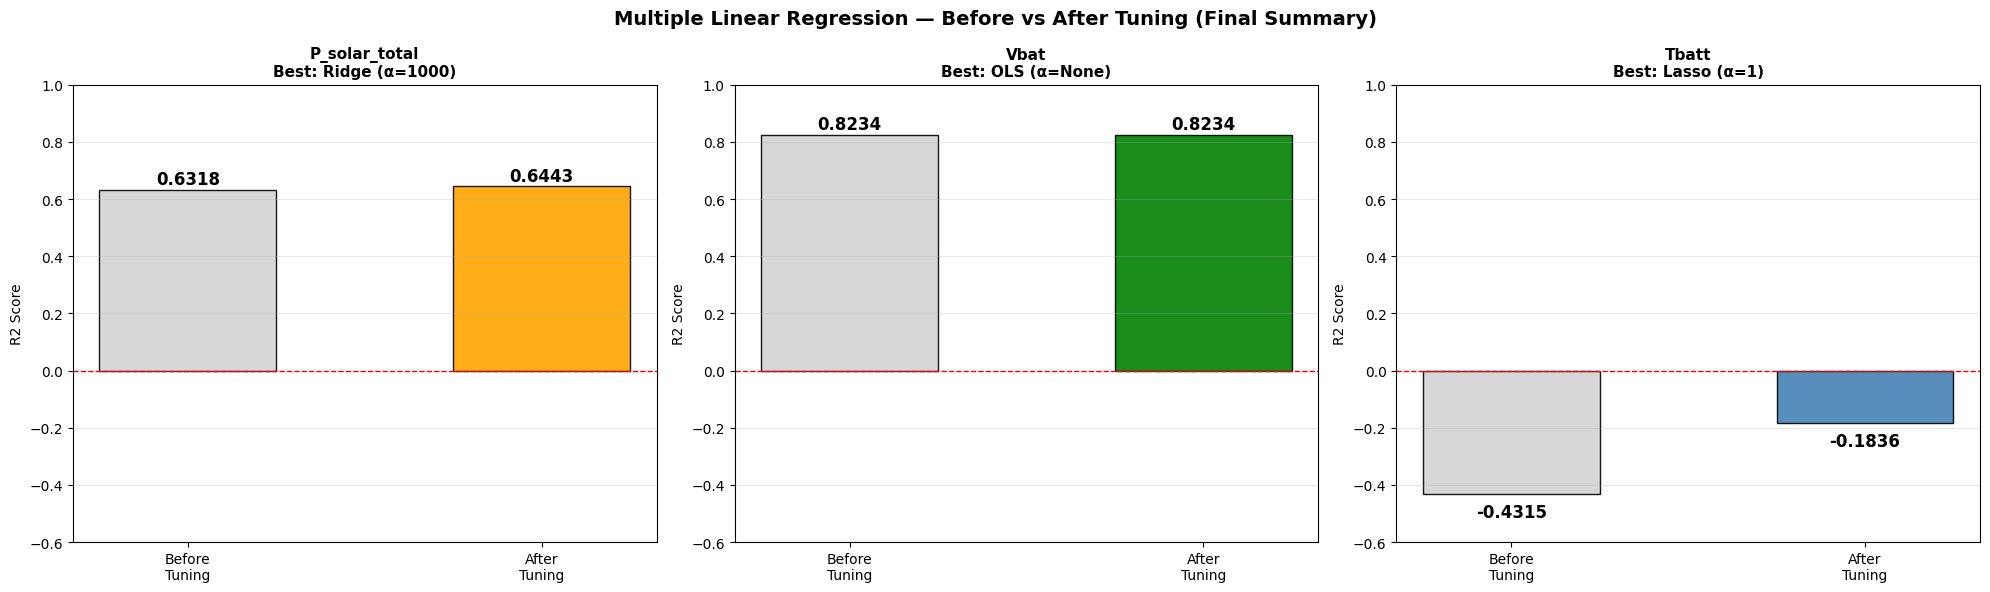

Final summary saved.


In [13]:
# ============================================================
# SECTION 11: FINAL SUMMARY VISUALIZATION
# Before vs After — all three targets
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Multiple Linear Regression — Before vs After Tuning (Final Summary)',
             fontsize=14, fontweight='bold')

target_names = ['P_solar_total', 'Vbat', 'Tbatt']
colors       = ['orange', 'green', 'steelblue']
name_keys    = ['Primary', 'Secondary', 'Tertiary']

for idx, (name, tname, clr) in enumerate(
        zip(name_keys, target_names, colors)):
    ax  = axes[idx]
    b   = results_before[name]
    a   = results_after[name]
    r2_vals = [b['R2'], a['R2']]

    bars = ax.bar(['Before\nTuning', 'After\nTuning'],
                  r2_vals,
                  color=['lightgray', clr],
                  edgecolor='black', alpha=0.9, width=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{tname}\nBest: {a["model_type"]} (α={a["alpha"]})',
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('R2 Score')
    ax.set_ylim([-0.6, 1.0])
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, r2_vals):
        ypos = bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.08
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('08_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final summary saved.")

# MULTIPLE LINEAR REGRESSION — CONCLUSION
### Dataset: TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)

---

## ALGORITHM

Multiple Linear Regression fits a hyperplane across all selected features:

> y = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ

Coefficients are optimized using **OLS (Ordinary Least Squares)** minimization — minimizing the sum of squared residuals between actual and predicted values.

---

## TRAINING OPTIMIZATION — OLS MINIMIZATION

- Coefficients estimated by solving the normal equations  
- StandardScaler applied so all features contribute equally  
- Target-specific feature sets used to eliminate data leakage (see Polynomial notebook)  

---

## HYPERPARAMETER TUNING — FEATURE INTERACTION SELECTION (MINIMAL)

- **Step 1:** OLS p-value analysis identified statistically significant features (p ≤ 0.05)  
- **Step 2:** Refined model trained on significant features only  
- **Step 3:** GridSearchCV tested Ridge (L2) and Lasso (L1) regularization  

| Target         | Best Model | Alpha | Before R² | After R² | Change   |
|----------------|------------|-------|-----------|----------|----------|
| P_solar_total  | Ridge      | 1000  | 0.6318    | 0.6443   | +1.99%   |
| Vbat           | OLS        | N/A   | 0.8234    | 0.8234   | +0.00%   |
| Tbatt          | Lasso      | 1     | -0.4315   | -0.1836  | +57.45%  |

---

## CROSS VALIDATION (5-fold TimeSeriesSplit)

- **P_solar_total:** Mean R² = 0.6512 ± 0.0268 — stable  
- **Vbat:** Mean R² = 0.8386 ± 0.0200 — very stable  
- **Tbatt:** Mean R² = −0.2747 ± 0.5748 — unstable (thermal dynamics too complex)  

---

## VIF ANALYSIS — CRITICAL FINDING

- Panel voltages + V_panel_avg show **VIF = ∞** (perfect multicollinearity)  
- V_panel_avg is the arithmetic mean of the 5 panel voltages  
- Ridge regularization (alpha = 1000) was essential to handle this  

---

## Reference

Jara et al. (2022), *Data in Brief*, DOI: 10.1016/j.dib.2022.108697